In [1]:
import sys

sys.path.insert(0, "..")

from pathlib import Path
import librosa
from IPython.display import Audio, display
import pygaborstm as stm
from nb_utils import save_three_tones, save_noise, save_harmonic_complexes

print(f"PyGaborSTM version: {stm.__version__}")

DATA_DIR = Path("../data")
STIMULI_DIR = DATA_DIR / "chi2005_stimuli"
ASSETS_DIR = Path("assets/chi2005_stimuli")
RIPPLE_DIR = DATA_DIR / "mvripfft"
SR = 16000
DURATION = 3.0  # snippet duration

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"ASSETS_DIR: {ASSETS_DIR.resolve()}")
print(f"STIMULI_DIR: {STIMULI_DIR.resolve()}")
print(f"RIPPLE_DIR: {RIPPLE_DIR.resolve()}")

PyGaborSTM version: 0.1.0
DATA_DIR: /root/JHU-LCAP/PyGaborSTM/data
ASSETS_DIR: /root/JHU-LCAP/PyGaborSTM/notebooks/assets/chi2005_stimuli
STIMULI_DIR: /root/JHU-LCAP/PyGaborSTM/data/chi2005_stimuli
RIPPLE_DIR: /root/JHU-LCAP/PyGaborSTM/data/mvripfft


/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
config = stm.Config(use_gpu=False, resolution="medium")
model = stm.PyGaborSTM(config)

In [3]:
def load_snippet(filepath, duration=DURATION, start=0):
    """Load audio snippet with librosa."""
    audio, _ = librosa.load(filepath, sr=SR)
    start_idx = int(start * SR)
    end_idx = start_idx + int(duration * SR)
    return (
        audio[start_idx:end_idx]
        if len(audio) > end_idx
        else audio[: int(duration * SR)]
    )

In [4]:
def process_and_plot(files, titles, suptitle, start=0, plot_rsf=True):
    """Load files, compute spectrograms, plot, and play audio."""
    spec_data, rsf_data, audios = [], [], []
    starts = start if isinstance(start, list) else [start] * len(files)

    for filepath, title, st in zip(files, titles, starts):
        if filepath.exists():
            audio = load_snippet(filepath, start=st)
            spec = model.spectrogram(audio)
            spec_data.append({"spectrogram": spec, "title": title})
            audios.append((audio, title))

            if plot_rsf:
                rsf = model.rsf(spec)
                rsf_data.append({"rsf": rsf, "title": title})
        else:
            print(f"Warning: {filepath.name} not found")

    if spec_data:
        # Plot spectrograms
        stm.plot.plt_spectrogram_grid(spec_data, suptitle=suptitle)

        # Plot RSFs
        if plot_rsf and rsf_data:
            stm.plot.plt_rsf_grid(rsf_data, suptitle=f"RSF — {suptitle}", fold=True)

        # Play audio samples
        print("Audio Samples:")
        for audio, label in audios:
            print(f"  {label}: {len(audio) / SR:.2f}s")
            display(Audio(audio, rate=SR))

In [5]:
STIMULI_DIR.mkdir(parents=True, exist_ok=True)

if not (STIMULI_DIR / "tone_250Hz.wav").exists():
    print("Generating tones...")
    save_three_tones(STIMULI_DIR)
if not (STIMULI_DIR / "broadband_noise.wav").exists():
    print("Generating noise...")
    save_noise(STIMULI_DIR)
if not (STIMULI_DIR / "harmonic_complex_F080_in_phase.wav").exists():
    print("Generating harmonics...")
    save_harmonic_complexes(STIMULI_DIR)

print("Files:", [f.name for f in sorted(STIMULI_DIR.glob("*.wav"))])

Files: ['Ferrofluid - Jealousy.wav', 'NonSpeech-01.wav', 'NonSpeech-02.wav', 'Speech-female-01.wav', 'Speech-female-02.wav', 'Speech-male-01.wav', 'Speech-male-02.wav', 'TelemannSuiteAmajor.wav', 'broadband_noise.wav', 'harmonic_complex_F080_in_phase.wav', 'harmonic_complex_F080_random_phase.wav', 'tone_1000Hz.wav', 'tone_250Hz.wav', 'tone_4000Hz.wav']


## Three-Tone Responeses (spectrogram and mrf)

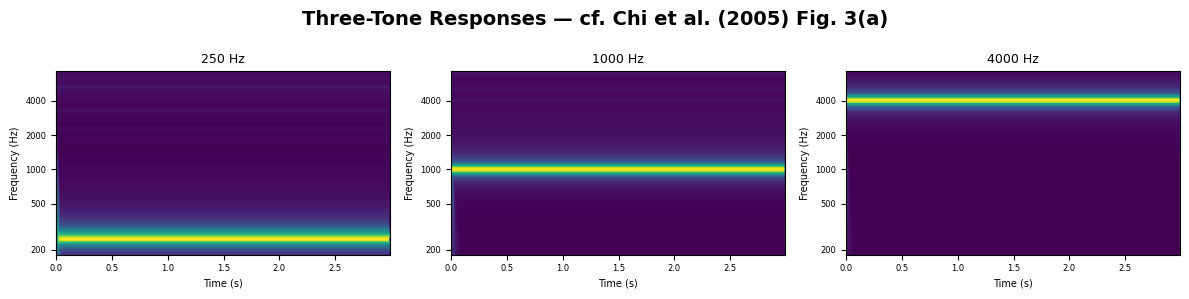

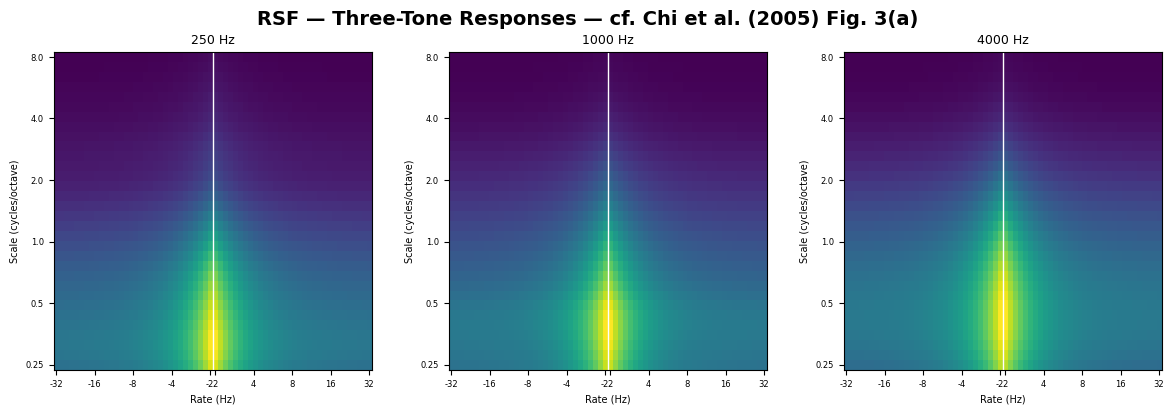

Audio Samples:
  250 Hz: 3.00s


  1000 Hz: 3.00s


  4000 Hz: 3.00s


In [6]:
files = [STIMULI_DIR / f"tone_{f}Hz.wav" for f in [250, 1000, 4000]]
titles = ["250 Hz", "1000 Hz", "4000 Hz"]
process_and_plot(
    files, titles, "Three-Tone Responses — cf. Chi et al. (2005) Fig. 3(a)"
)

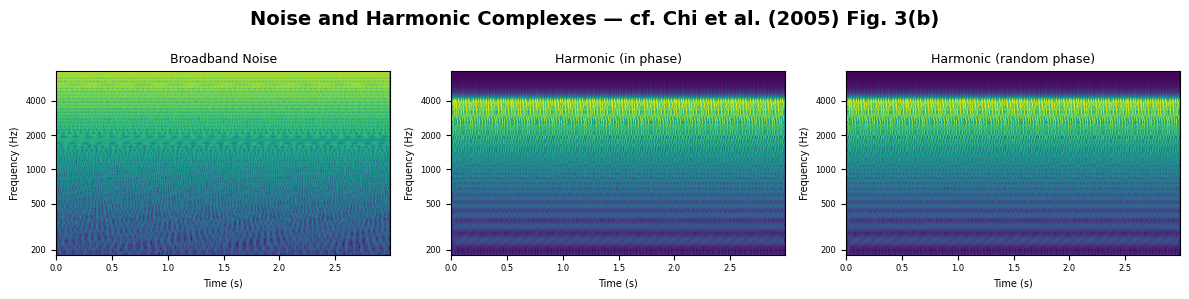

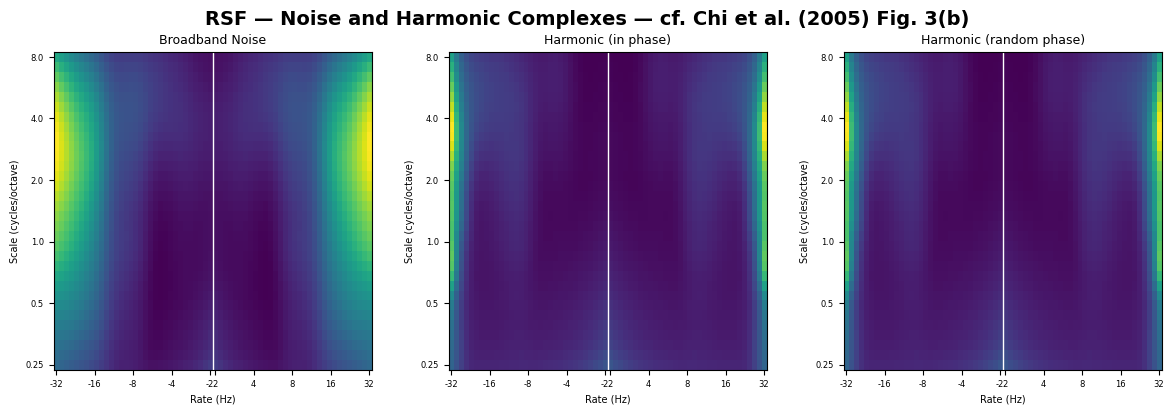

Audio Samples:
  Broadband Noise: 3.00s


  Harmonic (in phase): 3.00s


  Harmonic (random phase): 3.00s


In [7]:
files = [
    STIMULI_DIR / "broadband_noise.wav",
    STIMULI_DIR / "harmonic_complex_F080_in_phase.wav",
    STIMULI_DIR / "harmonic_complex_F080_random_phase.wav",
]
titles = ["Broadband Noise", "Harmonic (in phase)", "Harmonic (random phase)"]
process_and_plot(
    files, titles, "Noise and Harmonic Complexes — cf. Chi et al. (2005) Fig. 3(b)"
)

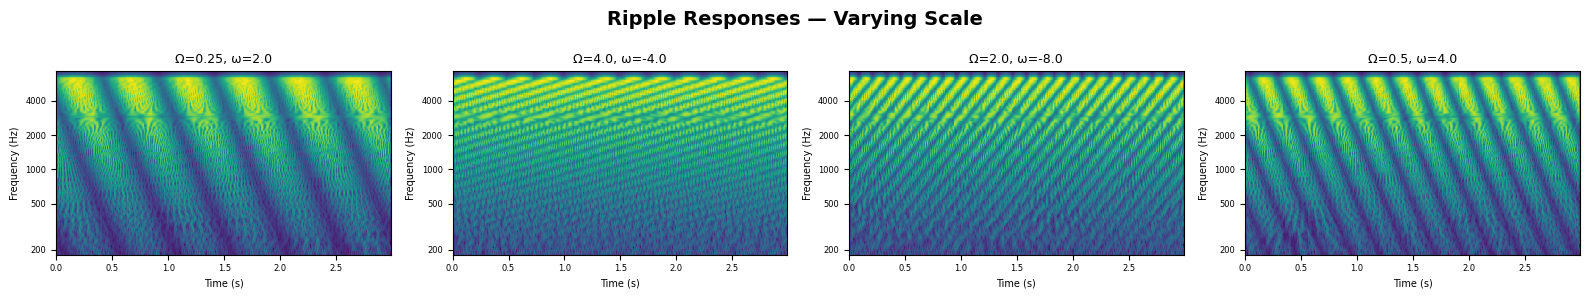

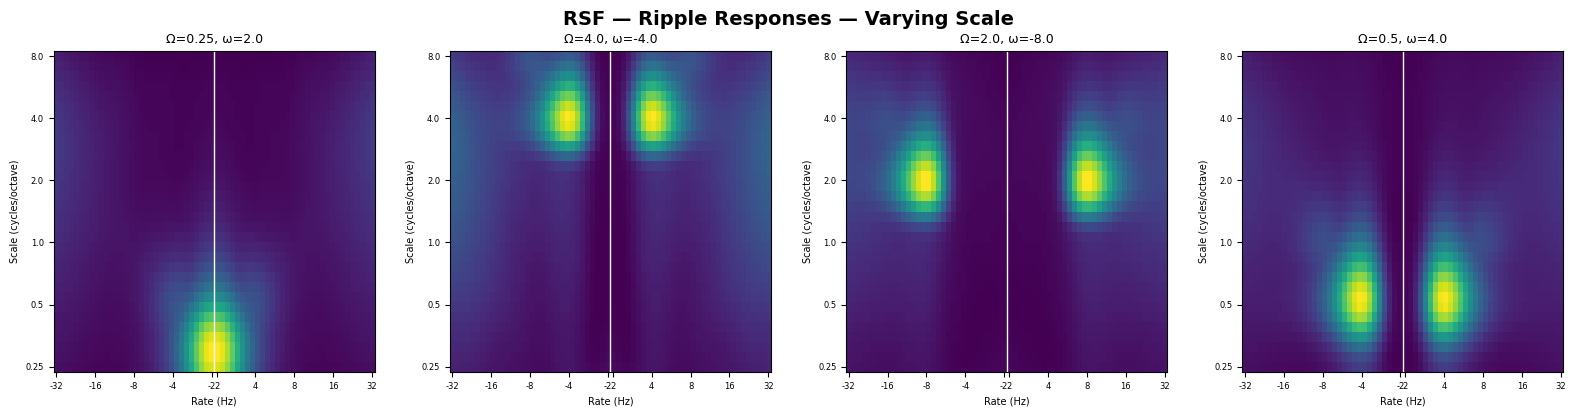

Audio Samples:
  Ω=0.25, ω=2.0: 3.00s


  Ω=4.0, ω=-4.0: 3.00s


  Ω=2.0, ω=-8.0: 3.00s


  Ω=0.5, ω=4.0: 3.00s


In [12]:
if RIPPLE_DIR.exists():
    files = [
        RIPPLE_DIR / f
        for f in [
            "ripple_31_R2.00_S0.25.wav",
            "ripple_23_R-4.00_S4.00.wav",
            "ripple_16_R-8.00_S2.00.wav",
            "ripple_38_R4.00_S0.50.wav",
        ]
    ]
    titles = ["Ω=0.25, ω=2.0", "Ω=4.0, ω=-4.0", "Ω=2.0, ω=-8.0", "Ω=0.5, ω=4.0"]
    process_and_plot(files, titles, "Ripple Responses — Varying Scale")
else:
    print(f"Ripple directory not found: {RIPPLE_DIR}")

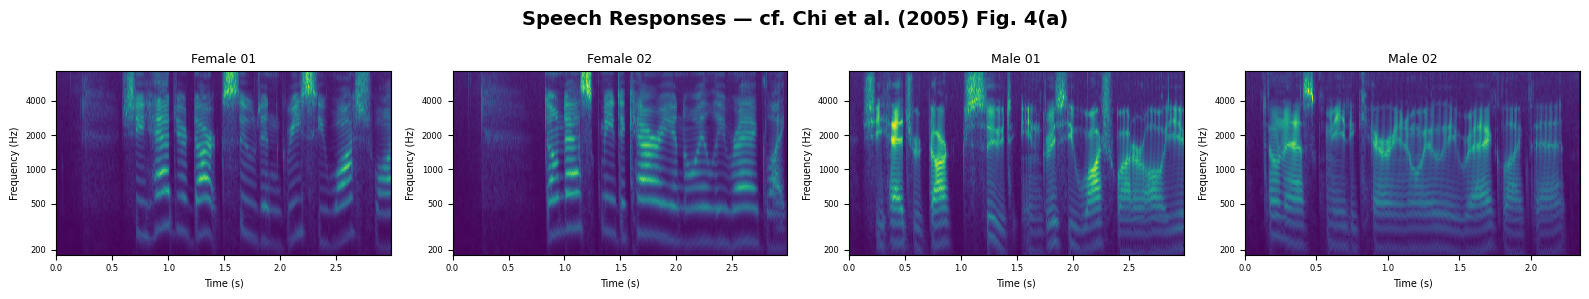

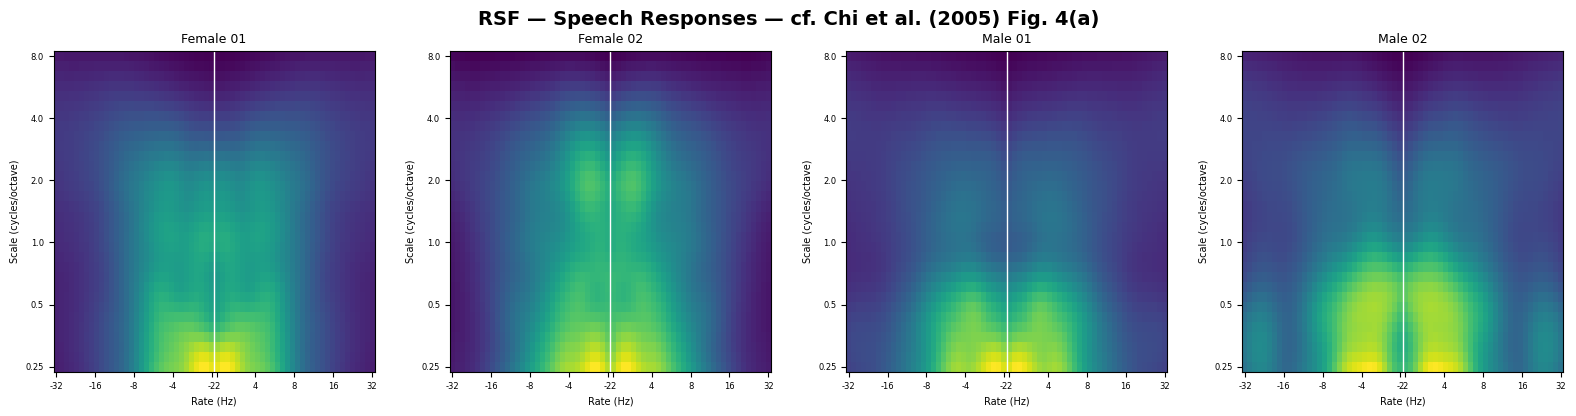

Audio Samples:
  Female 01: 3.00s


  Female 02: 3.00s


  Male 01: 3.00s


  Male 02: 2.35s


In [9]:
files = [
    ASSETS_DIR / f
    for f in [
        "Speech-female-01.wav",
        "Speech-female-02.wav",
        "Speech-male-01.wav",
        "Speech-male-02.wav",
    ]
]
titles = ["Female 01", "Female 02", "Male 01", "Male 02"]
process_and_plot(files, titles, "Speech Responses — cf. Chi et al. (2005) Fig. 4(a)")

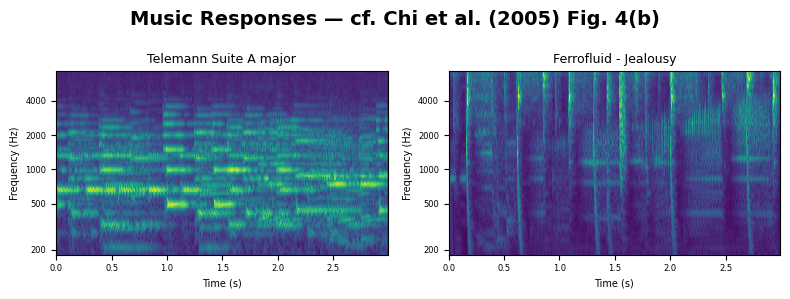

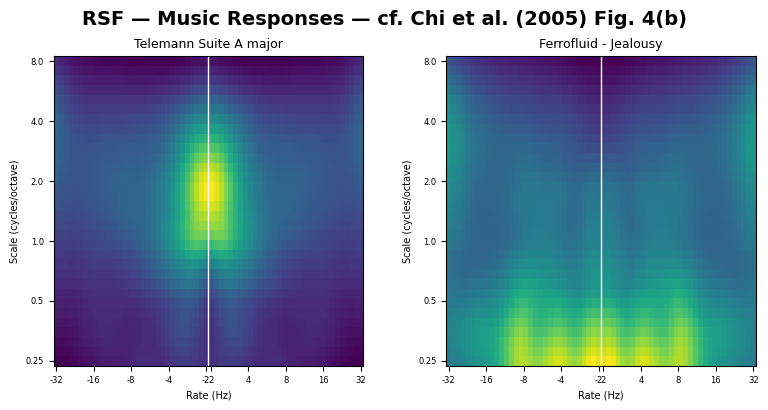

Audio Samples:
  Telemann Suite A major: 3.00s


  Ferrofluid - Jealousy: 3.00s


In [10]:
files = [
    ASSETS_DIR / f for f in ["TelemannSuiteAmajor.wav", "Ferrofluid - Jealousy.wav"]
]
titles = ["Telemann Suite A major", "Ferrofluid - Jealousy"]
process_and_plot(
    files,
    titles,
    "Music Responses — cf. Chi et al. (2005) Fig. 4(b)",
    start=[25.0, 40.0],
)

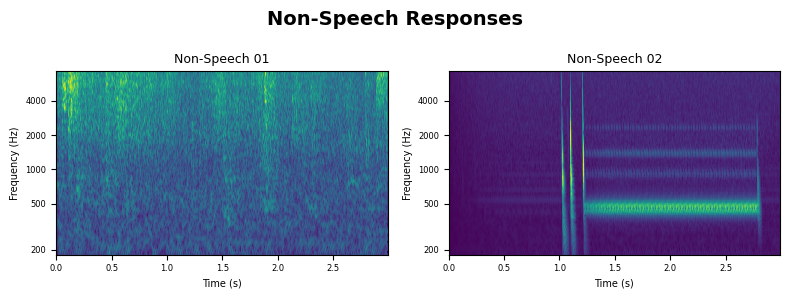

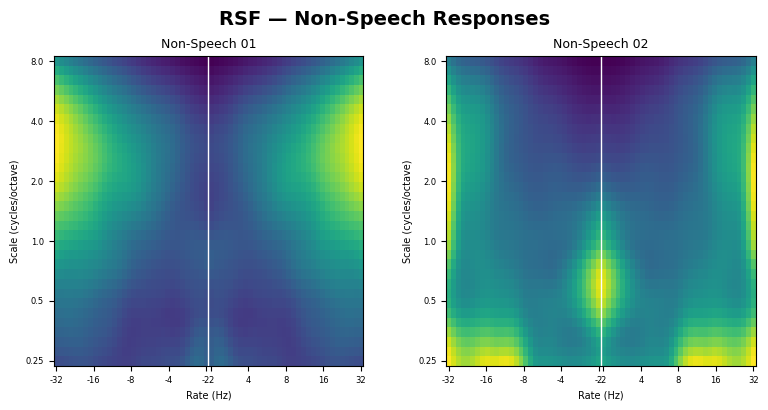

Audio Samples:
  Non-Speech 01: 3.00s


  Non-Speech 02: 3.00s


In [11]:
files = [ASSETS_DIR / f for f in ["NonSpeech-01.wav", "NonSpeech-02.wav"]]
titles = ["Non-Speech 01", "Non-Speech 02"]
process_and_plot(files, titles, "Non-Speech Responses", start=[38.0, 50.0])